In [4]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


In [6]:
clean_df = pd.read_csv('../data/clean_resume_data.csv')

In [7]:
clean_df.shape

(2484, 3)

In [8]:
clean_df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

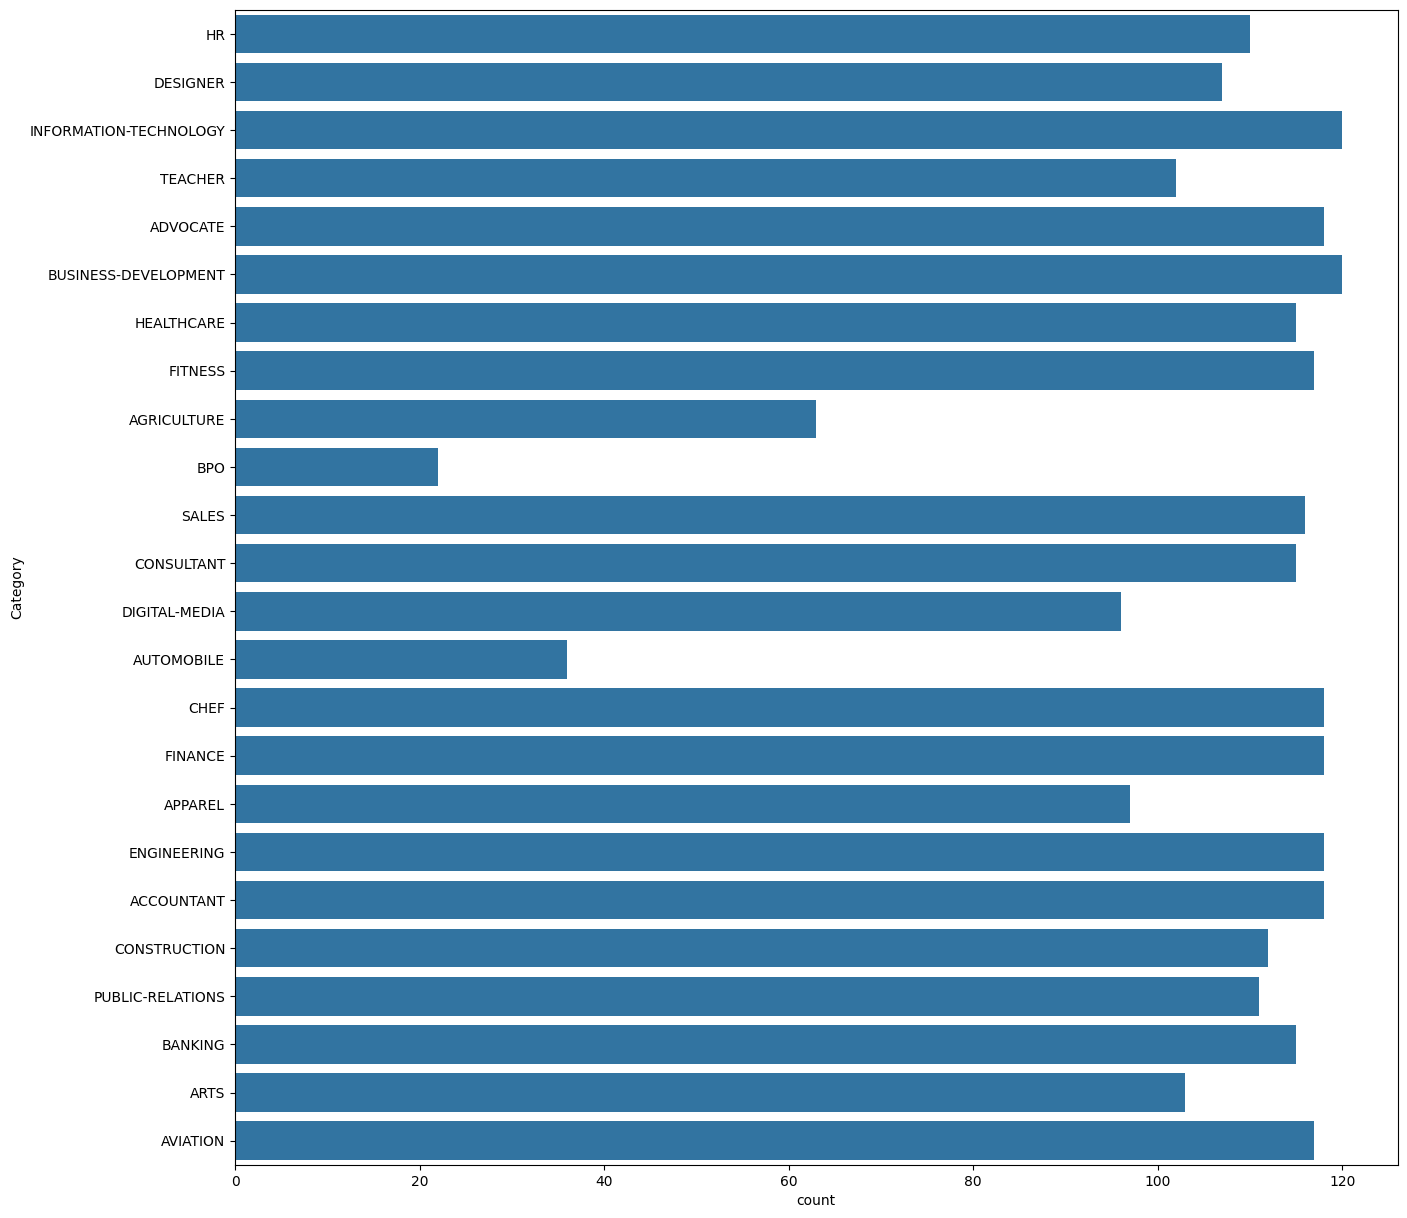

In [9]:
plt.figure(figsize=(15,15))
sns.countplot(clean_df['Category'])
plt.show()

In [10]:
clean_df['Category'].unique()

array(['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)

## balance the dataset

In [11]:
clean_df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [12]:
from sklearn.utils import resample

max_count = clean_df['Category'].value_counts().max()

balanced_data = []
for category in clean_df['Category'].unique():
    category_data   =clean_df[clean_df['Category']==category]
    if len(category_data) < max_count:
        balanced_category_data = resample(category_data,replace=True,n_samples=max_count,random_state=42)
    else:
        balanced_category_data = resample(category_data,replace=False,n_samples=max_count,random_state=42)
    balanced_data.append(balanced_category_data)

balanced_df = pd.concat(balanced_data)

In [13]:
balanced_df

,ID,Category,Feature
102,10399912,HR,hr personnel assistant summary u citizen autho...
51,39650734,HR,hr assistant summary hard worker dedicated det...
92,23510685,HR,global hr manager summary global hr profession...
14,27490876,HR,hr coordinator summary applicant screening bac...
106,24402267,HR,designation hr assistant professional summary ...
...,...,...,...
2390,26888302,AVIATION,aviation fuel quality control specialist profe...
2392,81588968,AVIATION,superintendent ii summary solutions focused ve...
2455,27512470,AVIATION,assistant cfo professional summary dedicated f...
2426,25718772,AVIATION,tso floater career overview obtain position fa...


In [14]:
balanced_df['Category'].value_counts()

Category
HR                        120
DESIGNER                  120
ARTS                      120
BANKING                   120
PUBLIC-RELATIONS          120
CONSTRUCTION              120
ACCOUNTANT                120
ENGINEERING               120
APPAREL                   120
FINANCE                   120
CHEF                      120
AUTOMOBILE                120
DIGITAL-MEDIA             120
CONSULTANT                120
SALES                     120
BPO                       120
AGRICULTURE               120
FITNESS                   120
HEALTHCARE                120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  120
TEACHER                   120
INFORMATION-TECHNOLOGY    120
AVIATION                  120
Name: count, dtype: int64

In [15]:
# balanced_df.isnull().sum()
balanced_df.dropna(inplace=True)

##TTS

In [16]:
X = balanced_df['Feature']
y = balanced_df['Category']
X_train, X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42)

## ENCODING

In [17]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
X_train_tfidf  = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf= tfidf_vectorizer.transform(X_test)

## Random forest classifier

In [18]:
from sklearn.metrics import classification_report

rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train_tfidf,y_train )

y_pred=  rf_classifier.predict(X_test_tfidf)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.890625


In [19]:
print(classification_report(y_test,y_pred))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.86      0.90      0.88        21
              ADVOCATE       0.96      0.83      0.89        29
           AGRICULTURE       0.95      0.78      0.86        23
               APPAREL       1.00      0.90      0.95        21
                  ARTS       1.00      0.68      0.81        22
            AUTOMOBILE       1.00      1.00      1.00        19
              AVIATION       0.97      1.00      0.98        30
               BANKING       0.94      0.74      0.83        23
                   BPO       1.00      1.00      1.00        15
  BUSINESS-DEVELOPMENT       0.81      0.94      0.87        18
                  CHEF       0.90      0.96      0.93        28
          CONSTRUCTION       0.89      1.00      0.94        25
            CONSULTANT       0.86      0.77      0.81        31
              DESIGNER       0.96      0.96      0.96        28
         DIGITAL-MEDIA       0.95      

## Predictive system

In [20]:
import re

def cleanResume(txt):
    cleanText = re.sub('http\S+\s*', ' ', txt)
    cleanText = re.sub('RT|cc', ' ', cleanText)
    cleanText = re.sub('#\S+', '', cleanText)
    cleanText = re.sub('@\S+', ' ', cleanText)
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~"""), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)
    cleanText = re.sub('\s+', ' ', cleanText)
    return cleanText



def predict_category(resume_text):
    resume_text = cleanResume(resume_text)
    resume_tfidf=  tfidf_vectorizer.transform([resume_text])
    predicted_category = rf_classifier.predict(resume_tfidf)[0]
    return predicted_category

## Save files

In [21]:
import pickle 
pickle.dump(rf_classifier,open('../models/rf_classifier_categorization.pkl','wb'))
pickle.dump(tfidf_vectorizer,open('../models/tfidf_vectorizer_categorization.pkl','wb'))